In [1]:
import pandas as pd
df = pd.read_csv(r'C:\Users\arpan\Downloads\titanic\train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:

print("Shape:", df.shape)


print("\nMissing values:")
print(df.isnull().sum())


df.describe()

Shape: (891, 12)

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:

df = df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'])


df['Age'] = df['Age'].fillna(df['Age'].median())


df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})


df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})


print("Missing values after cleaning:")
print(df.isnull().sum())
df.head()

Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,0
1,1,1,0,38.0,1,0,71.2833,1
2,1,3,0,26.0,0,0,7.9250,0
3,1,1,0,35.0,1,0,53.1000,0
4,0,3,1,35.0,0,0,8.0500,0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


X = df.drop(columns=['Survived'])
y = df['Survived']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 82.12%


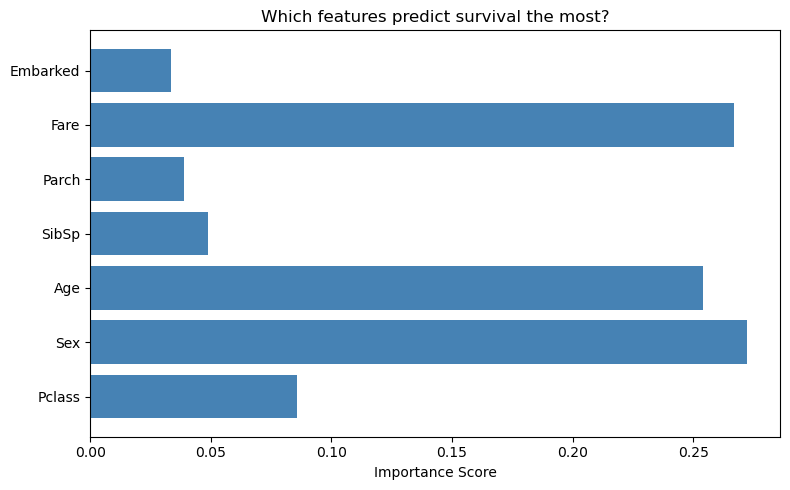

In [5]:
import matplotlib.pyplot as plt


features = X.columns
importances = model.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(features, importances, color='steelblue')
plt.xlabel('Importance Score')
plt.title('Which features predict survival the most?')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [ ]:

test_df = pd.read_csv(r'C:\Users\arpan\Downloads\titanic\test.csv')

# Apply same cleaning as training data
test_df = test_df.drop(columns=['Cabin', 'Ticket', 'Name', 'PassengerId'])
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])
test_df['Sex'] = test_df['Sex'].map({'male': 1, 'female': 0})
test_df['Embarked'] = test_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})


test_predictions = model.predict(test_df)


test_original = pd.read_csv(r'C:\Users\arpan\Downloads\titanic\test.csv')
submission = pd.DataFrame({
    'PassengerId': test_original['PassengerId'],
    'Survived': test_predictions
})
submission.to_csv(r'C:\Users\arpan\Downloads\titanic\submission.csv', index=False)
print("Submission file created!")
print(submission.head())

Submission file created!
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         1
